In [2]:
from mylib.statistic_test import *
from mazepy.datastruc.neuact import SpikeTrain, TuningCurve
from mazepy.datastruc.variables import VariableBin

code_id = "0877 - Revisit Stability"
loc = join(figpath, "Dsp", code_id)
mkdir(loc)
saved_dir = join(loc, "Retrieval Results")
dir_name = join(figpath, "Dsp", "Reforming Neural Trajectory Analysis") 
mkdir(saved_dir)
pass

d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


        D:\Data\FinalResults\Dsp\0877 - Revisit Stability is already existed!
        D:\Data\FinalResults\Dsp\0877 - Revisit Stability\Retrieval Results is already existed!


In [3]:
from scipy.optimize import curve_fit

# logistic function
def logistic(t, k, t0):
    return 1 / (1 + np.exp(-k * (t - t0)))

def gaussian_kernel(x, sigma=1.0):
    """Gaussian kernel function."""
    y = np.exp(-0.5 * (x / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    return y/np.sum(y)

def hidden_state_proportion(
    mouse: int,
    maze_type: int,
    rt: int = 0
):
    if exists(join(saved_dir, f"{mouse}_behav_R{rt+1}.pkl")):
        with open(join(saved_dir, f"{mouse}_behav_R{rt+1}.pkl"), 'rb') as f:
            return pickle.load(f)
    else:
        with open(join(dir_name, f"{mouse}.pkl"), 'rb') as f:
            res = pickle.load(f)
            
        hidden_state_traj = res['raw_hidden_state_traj']
        session_traj = res['raw_session_traj']
        route_traj = res['raw_route_traj']
        nodes_traj = res['raw_nodes_traj']
        father_nodes_traj = S2F[nodes_traj-1]
        lap_traj = res['raw_lap_traj']
        time_traj = res['raw_time_traj']
        dt = np.zeros_like(time_traj, np.float64)
        
        beg = np.concatenate(([0], np.where(np.diff(lap_traj) != 0)[0] + 1))
        end = np.concatenate((np.where(np.diff(lap_traj) != 0)[0] + 1, [len(lap_traj)]))
        for i in range(len(beg)):
            dt[beg[i]:end[i]] = np.diff(time_traj[beg[i]:end[i]], prepend=time_traj[beg[i]])
        
        if rt == 0:
            state_sum = np.zeros((144, 7*4))
            time_sum = np.zeros((144, 7*4))
            for s in range(7):
                n_lap = np.unique(lap_traj[(route_traj == 0) & (session_traj == s)])
                
                division = np.concatenate([np.arange(0, n_lap.shape[0], int(n_lap.shape[0]/4)+1), [n_lap.shape[0]]])
                for i in range(division.shape[0]-1):
                    for b in CP_DSPs[maze_type][0]:
                        idx = np.where(
                            (np.isin(lap_traj, n_lap[division[i]:division[i+1]])) &
                            (session_traj == s) &
                            (route_traj == 0) & 
                            (father_nodes_traj == b)
                        )[0]
                        
                        if idx.shape[0] < 1:
                            continue                
                    
                        state_sum[b-1, s*4 + i] = np.sum((1-hidden_state_traj[idx]) * dt[idx])
                        time_sum[b-1, s*4 + i] = np.sum(dt[idx])
            
            prop = np.zeros((144, 7*4))
            for j in range(prop.shape[1]):
                
                prop[CP_DSPs[maze_type][0]-1, j] = (
                    np.convolve(state_sum[CP_DSPs[maze_type][0]-1, j], np.ones(7), mode='same') /
                    np.convolve(time_sum[CP_DSPs[maze_type][0]-1, j], np.ones(7), mode='same')
                )
            
            with open(join(saved_dir, f"{mouse}_behav_R{rt+1}.pkl"), 'wb') as f:
                pickle.dump(prop, f)
            
            return prop
        else:
            state_sum = np.zeros((144, 7))
            time_sum = np.zeros((144, 7))
            for s in range(7):
                for b in CP_DSPs[maze_type][rt]:
                    idx = np.where(
                        (route_traj == rt) &
                        (session_traj == s) & 
                        (father_nodes_traj == b)
                    )[0]
                    
                    if idx.shape[0] < 1:
                        continue
                    
                    state_sum[b-1, s] = np.sum((1-hidden_state_traj[idx]) * dt[idx])
                    time_sum[b-1, s] = np.sum(dt[idx])
                    
            prop = np.zeros((144, 7))
            for j in range(prop.shape[1]):
                prop[CP_DSPs[maze_type][rt]-1, j] = (
                    np.convolve(state_sum[CP_DSPs[maze_type][rt]-1, j], np.ones(7), mode='same') /
                    np.convolve(time_sum[CP_DSPs[maze_type][rt]-1, j], np.ones(7), mode='same')
                )
                
            #if rt == 3:
            #    prop *= np.nan
            if rt == 6:
                convert_session = np.where(session_convertor[mouse] >= 0)[0][0]
                prop[:, convert_session:] = np.nan
                
            with open(join(saved_dir, f"{mouse}_behav_R{rt+1}.pkl"), 'wb') as f:
                pickle.dump(prop, f)
            return prop

maze_type = 1
for mouse in [10212, 10224, 10227, 10232, 10275, 10276]:
    for r in range(7):
        hidden_state_proportion(mouse, maze_type, r)
prop_r0 = hidden_state_proportion(10232, maze_type, 0)

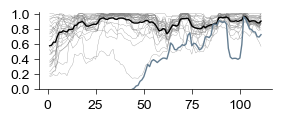

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20560\451961902.py:53: RuntimeWarning: divide by zero encountered in divide
  prop_r5[CP_DSPs[maze_type][5]-1, 0]/mean_prop_r0[CP_DSPs[maze_type][5]-1],


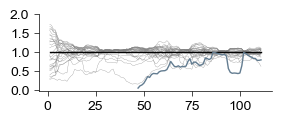

In [4]:
maze_type = 1
prop_r0 = hidden_state_proportion(10232, maze_type, 0)
prop_r5 = hidden_state_proportion(10232, maze_type, 5)
fig = plt.figure(figsize=(3, 1))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
for i in range(prop_r0.shape[1]):
    ax.plot(
        np.arange(1, 112),
        prop_r0[CP_DSPs[maze_type][0]-1, i],
        color='grey',
        lw=0.2
    )
ax.plot(
    np.arange(1, 112),
    np.nanmean(prop_r0[CP_DSPs[maze_type][0]-1, :], axis=1),
    color='k',
    lw=1
)
#idx = np.where(prop_r5[CP_DSPs[maze_type][5]-1, 0] - bottom_line_whole[CP_DSPs[maze_type][5]-1] >= 0)[0]
ax.plot(
    np.arange(1, 112)[-CP_DSPs[maze_type][5].shape[0]:],
    prop_r5[CP_DSPs[maze_type][5]-1, 0],
    color=DSPPalette[5],
    lw=1
)
ax.set_ylim(0, 1.02)
ax.set_yticks(np.linspace(0, 1, 6))
plt.savefig(join(loc, "Hidden State Retrieval [Example].png"), dpi=600)
plt.savefig(join(loc, "Hidden State Retrieval [Example].svg"), dpi=600)
plt.show()


maze_type = 1
mean_prop_r0 = np.nanmean(prop_r0, axis=1)
fig = plt.figure(figsize=(3, 1))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
for i in range(prop_r0.shape[1]):
    ax.plot(
        np.arange(1, 112),
        prop_r0[CP_DSPs[maze_type][0]-1, i]/mean_prop_r0[CP_DSPs[maze_type][0]-1],
        color='grey',
        lw=0.2
    )
ax.plot(
    np.arange(1, 112),
    np.nanmean(prop_r0[CP_DSPs[maze_type][0]-1, :], axis=1)/mean_prop_r0[CP_DSPs[maze_type][0]-1],
    color='k',
    lw=1
)
#idx = np.where(prop_r5[CP_DSPs[maze_type][5]-1, 0] - bottom_line_whole[CP_DSPs[maze_type][5]-1] >= 0)[0]
ax.plot(
    np.arange(1, 112)[-CP_DSPs[maze_type][5].shape[0]:],
    prop_r5[CP_DSPs[maze_type][5]-1, 0]/mean_prop_r0[CP_DSPs[maze_type][5]-1],
    color=DSPPalette[5],
    lw=1
)
ax.set_yticks(np.linspace(0, 2, 5))
plt.savefig(join(loc, "Hidden State Retrieval [Normed Example].png"), dpi=600)
plt.savefig(join(loc, "Hidden State Retrieval [Normed Example].svg"), dpi=600)
plt.show()

In [ ]:
def get_index_map(mouse: int) -> np.ndarray:
    idx = np.where(f_CellReg_dsp['MiceID'] == mouse)[0][0]
    with open(f_CellReg_dsp['cellreg_folder'][idx], 'rb') as f:
        index_map = pickle.load(f).astype(np.int64)
        
    if mouse not in [10232, 10275, 10276]:
        index_map = index_map[1:, :]
    
    return index_map

def cross_day_stability(mouse, rt: int):
    if exists(join(saved_dir, f"{mouse}_neural.pkl")):
        with open(join(saved_dir, f"{mouse}_neural.pkl"), 'rb') as f:
            cross_day_stability = pickle.load(f)
        
        if rt == 0:
            return np.stack((cross_day_stability[:, :, 0], cross_day_stability[:, :, 4]), axis=2)
        else:
            if rt in [1,2,3]:
                return cross_day_stability[:, :, rt:rt+1]
            else:
                return cross_day_stability[:, :, rt+1:rt+2]
    else:
        file_idx = np.where(f2['MiceID'] == mouse)[0]
        index_map = get_index_map(mouse)
        
        traces = []
        print("Upload:")
        for i in tqdm(range(7)):
            with open(f2['Trace File'][file_idx[i]], 'rb') as f:
                trace = pickle.load(f)
            traces.append(trace)
            
        cross_day_corr = np.zeros((144, 6, 8, 2)) # Bin x Session x Route
        for s in tqdm(range(6)):
            cell_idx = np.where((index_map[s, :] > 0) & (index_map[s+1, :] > 0))[0]
            
            for j, nodes in enumerate([0, 1, 2, 3, 5, 6, 7, 8]):
                rt_map_prev = traces[s][f'node {nodes}']['smooth_map_all'][index_map[s, cell_idx]-1, :]
                #rt_map_prev = traces[s][f'node {nodes}']['old_map_clear'][index_map[s, cell_idx]-1, :]
                rt_map_next = traces[s+1][f'node {nodes}']['smooth_map_all'][index_map[s+1, cell_idx]-1, :]
                #rt_map_next = traces[s+1][f'node {nodes}']['old_map_clear'][index_map[s+1, cell_idx]-1, :]
                for b in range(144):
                    sonbins = np.asarray(Father2SonGraph[b+1], dtype=np.int64)
                    """cross_day_corr[b, s, j, 0] = np.corrcoef(rt_map_prev[:, b], rt_map_next[:, b])[0, 1]
                    cross_day_corr[b, s, j, 1] = np.corrcoef(
                        np.random.permutation(rt_map_prev[:, b]), 
                        np.random.permutation(rt_map_next[:, b])
                    )[0, 1]
                    """
                    cross_day_corr[b, s, j, 0] = np.corrcoef(rt_map_prev[:, sonbins-1].flatten(), rt_map_next[:, sonbins-1].flatten())[0, 1]
                    cross_day_corr[b, s, j, 1] = np.corrcoef(
                        np.random.permutation(rt_map_prev[:, sonbins-1].flatten()), 
                        np.random.permutation(rt_map_next[:, sonbins-1].flatten())
                    )[0, 1]
                    
        with open(join(saved_dir, f"{mouse}_neural.pkl"), 'wb') as f:
            pickle.dump(cross_day_corr, f)
            
def apvc(mouse, rt):
    if exists(join(saved_dir, f"{mouse}_apvc.pkl")):
        with open(join(saved_dir, f"{mouse}_apvc.pkl"), 'rb') as f:
            apvc_data = pickle.load(f)
    else:
        file_idx = np.where(f2['MiceID'] == mouse)[0]
        
        apvc_data = np.zeros((144, 7, 8))
        for s in tqdm(range(7)):
            with open(f2['Trace File'][file_idx[s]], 'rb') as f:
                trace = pickle.load(f)

            for i, rt, nodes in zip(range(8), [1, 2, 3, 0, 4, 5, 6, 0], [1, 2, 3, 4, 6, 7, 8, 9]):
                if nodes < 5:
                    targ_nodes = 0
                else:
                    targ_nodes = 5
                    
                for b in range(144):
                    sonbins = np.asarray(Father2SonGraph[b+1], dtype=np.int64)
                    apvc_data[b, s, i] = np.corrcoef(
                        trace[f'node {nodes}']['smooth_map_all'][:, sonbins-1].flatten(),
                        trace[f'node {targ_nodes}']['smooth_map_all'][:, sonbins-1].flatten()
                    )[0, 1]
            
            del trace
                    
        with open(join(saved_dir, f"{mouse}_apvc.pkl"), 'wb') as f:
            pickle.dump(apvc_data, f)

    return apvc_data



maze_type = 1
def new_map_stability(mouse, rt: int):
    if exists(join(saved_dir, f" {mouse}_new_map.pkl")):
        with open(join(saved_dir, f"{mouse}_new_map.pkl"), 'rb') as f:
            cross_day_stability = pickle.load(f)
        
        if rt == 0:
            return np.concatenate((cross_day_stability[:, 0:1, :], cross_day_stability[:, 4:5, :]), axis=2)
        else:
            if rt in [1,2,3]:
                return cross_day_stability[:, rt:rt+1, :]
            else:
                return cross_day_stability[:, rt+1:rt+2, :]
    else:
        file_idx = np.where(f2['MiceID'] == mouse)[0]
        index_map = get_index_map(mouse)
        
        traces = []
        print("Upload:")
        for i in tqdm(range(7)):
            with open(f2['Trace File'][file_idx[i]], 'rb') as f:
                trace = pickle.load(f)
            traces.append(trace)
            
        cross_day_corr = np.zeros((6, 8, 2)) # Bin x Session x Route
        D = GetDMatrices(maze_type, 48)
        for s in range(6):
            cell_idx = np.where((index_map[s, :] > 0) & (index_map[s+1, :] > 0))[0]
            
            for j, nodes in enumerate([0, 1, 2, 3, 5, 6, 7, 8]):
                rt_map_prev = traces[s][f'node {nodes}']['smooth_map_all'][index_map[s, cell_idx]-1, :]
                rt_map_next = traces[s+1][f'node {nodes}']['smooth_map_all'][index_map[s+1, cell_idx]-1, :]
                
                if j in [0, 4]:
                    cross_day_corr[s, j, 0] = np.corrcoef(rt_map_prev[:, :].flatten(), rt_map_next[:, :].flatten())[0, 1]
                    cross_day_corr[s, j, 1] = np.corrcoef(
                        np.random.permutation(rt_map_prev[:, :].flatten()), 
                        np.random.permutation(rt_map_next[:, :].flatten())
                    )[0, 1]
                else:
                    if j in [1, 2, 3]:
                        targ_map_prev = traces[s][f'node 0']['smooth_map_all'][index_map[s, cell_idx]-1, :]
                        targ_map_next = traces[s+1][f'node 0']['smooth_map_all'][index_map[s+1, cell_idx]-1, :]
                        rt = j
                    else:
                        targ_map_prev = traces[s][f'node 5']['smooth_map_all'][index_map[s, cell_idx]-1, :]
                        targ_map_next = traces[s+1][f'node 5']['smooth_map_all'][index_map[s+1, cell_idx]-1, :]
                        rt = j-1
                        
                    retriev_curve_prev = np.zeros(CP_DSPs[maze_type][rt].shape[0]*16)
                    retriev_curve_next = np.zeros(CP_DSPs[maze_type][rt].shape[0]*16)
                    sonbins = np.concatenate([Father2SonGraph[b] for b in CP_DSPs[maze_type][rt]])
                    for k, b in enumerate(sonbins):
                        retriev_curve_prev[k] = np.corrcoef(rt_map_prev[:, b-1], targ_map_prev[:, b-1])[0, 1]
                        retriev_curve_next[k] = np.corrcoef(rt_map_next[:, b-1], targ_map_next[:, b-1])[0, 1]
                    retriev_curve_prev[np.isnan(retriev_curve_prev)] = 0
                    retriev_curve_next[np.isnan(retriev_curve_next)] = 0
                    
                    bin_argsort = np.argsort(D[sonbins-1, 2303])[::-1]
                    try:
                        retriv_point_prev = np.where(retriev_curve_prev[bin_argsort] > 0.25)[0][0]
                    except:
                        retriv_point_prev = retriev_curve_prev.shape[0]
                    try:
                        retriv_point_next = np.where(retriev_curve_next[bin_argsort] > 0.25)[0][0]
                    except:
                        retriv_point_next = retriev_curve_next.shape[0]
                
                    included_bins = sonbins[bin_argsort][:min(retriv_point_prev, retriv_point_next)]-1
                    
                    if included_bins.shape[0] >= 16:
                        cross_day_corr[s, j, 0] = np.corrcoef(rt_map_prev[:, included_bins].flatten(), rt_map_next[:, included_bins].flatten())[0, 1]
                        cross_day_corr[s, j, 1] = np.corrcoef(
                            np.random.permutation(rt_map_prev[:, included_bins].flatten()),
                            np.random.permutation(rt_map_next[:, included_bins].flatten())
                        )[0, 1]
                    else:
                        cross_day_corr[s, j, 0] = np.nan
                        cross_day_corr[s, j, 1] = np.nan
            
        with open(join(saved_dir, f"{mouse}_new_map.pkl"), 'wb') as f:
            pickle.dump(cross_day_corr, f)

for mouse in [10212, 10224, 10227, 10232, 10275, 10276]:
    new_map_stability(mouse, 0)
    cross_day_stability(mouse, 0)
    apvc_data = apvc(mouse, 0)

Upload:


 86%|████████▌ | 6/7 [00:06<00:01,  1.10s/it]

# Cross-day Stability Changes

576


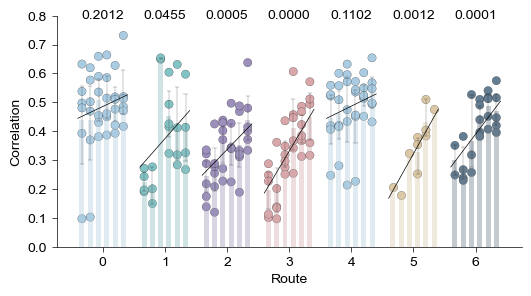

In [7]:
if exists(join(figdata, f" {code_id} [Cross-Day Stability Change].pkl")) == False:
    Stability = { 
        'MiceID': [],
        'Correlation': [],
        'Session': [],
        'Route': [],
        'Type': []
    }
    
    for mouse in [10212, 10224, 10227, 10232, 10275, 10276]:
        with open(join(saved_dir, f"{mouse}_new_map.pkl"), 'rb') as f:
            neural_stability = pickle.load(f)
            
        for s in range(6):
            rts = [0, 1, 2, 3, 0, 4, 5, 6]
            for j in range(8):
                for stype in ["Data", "Shuffle"]:
                    Stability['MiceID'].append(mouse)
                    Stability['Session'].append(s)
                    Stability['Route'].append(j)
                    Stability['Type'].append(stype)
                    Stability['Correlation'].append(neural_stability[s, j, 0] if stype == "Data" else neural_stability[s, j, 1])
        
    for key in Stability.keys():
        Stability[key] = np.array(Stability[key])   
    
    with open(join(figdata, f"{code_id} [Cross-Day Stability Change].pkl"), 'wb') as f:
        pickle.dump(Stability, f)
        
    StabilityD = pd.DataFrame(Stability)
    StabilityD.to_excel(join(figdata, f"{code_id} [Cross-Day Stability Change].xlsx"), index=False)
    print(len(StabilityD))
else:
    with open(join(figdata, f"{code_id} [Cross-Day Stability Change].pkl"), 'rb') as f:
        Stability = pickle.load(f)

SubData1 = SubDict(
    Stability, 
    Stability.keys(), 
    np.where((Stability['Type'] == "Data")&(Stability['Route'] != 7))[0]
)
fig = plt.figure(figsize=(6, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
colors = DSPPalette[:4] + DSPPalette[:1] + DSPPalette[4:7]
for rt in range(7):
    subdata_rt = SubDict(
        SubData1, 
        SubData1.keys(), 
        np.where((SubData1['Route'] == rt))[0]
    )
    sns.stripplot(
        data=subdata_rt,
        x='Route',
        y='Correlation',
        hue='Session',
        palette=[colors[rt]]*6,
        linewidth=0.15,
        edgecolor='k',
        size=6,
        dodge=True,
        jitter=0,
        ax=ax,
        zorder=1,
        legend=False
    )
    sns.barplot(
        data=subdata_rt,
        x='Route',
        y='Correlation',
        hue='Session',
        palette=[colors[rt]]*6,
        capsize=0.4, 
        err_kws={'linewidth': 0.15, 'color':'k'},
        ax=ax,
        legend=False,
        gap=0.4,
        width=0.8,
        zorder=2,
        alpha=0.4
    )
    idx = np.where(np.isnan(subdata_rt['Correlation']) == False)[0]
    reg = linregress(subdata_rt['Session'][idx], subdata_rt['Correlation'][idx])
    x = np.array([-0.4, +0.4])
    xx = np.array([0, 5])
    y = reg.slope * xx + reg.intercept
    ax.plot(x+rt, y, color='k', linewidth=0.5, zorder=3)
    ax.text(rt, 0.8, f"{reg.pvalue:.4f}", ha='center', va='center')
    
ax.set_ylim(0, 0.8)
plt.savefig(join(loc, f"Stability Increase.svg"), dpi=300)
plt.savefig(join(loc, f"Stability Increase.png"), dpi=300)
plt.show()

# Behavioral vs Cross Day Stability

0 p = 0.20884003480298188
1 p = 0.03124402835335779
2 p = 0.1282110490906328
3 p = nan
4 p = 0.35220658785032505
5 p = 0.4257700299302352


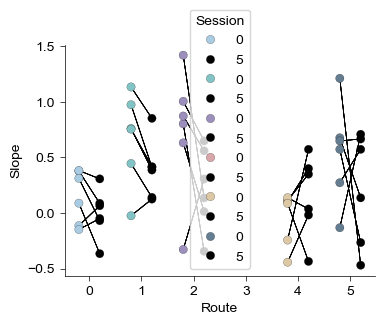

In [ ]:
if exists(join(figdata, f"{code_id} [Behav & Cross Day Stability].pkl")) == False:
    # code to generate and save the figure data
    BehavCrossStab = {
        "MiceID": [],
        "Session": [],
        "Slope": [],
        "Route": []
    }
    
    for mouse in [10212, 10224, 10227, 10232, 10275, 10276]:
        behav_prop_r0 = hidden_state_proportion(mouse, 1, 0)
        
        for s in range(6):
            mean_prop_r0 = np.nanmean(behav_prop_r0[:, s*4:(s+1)*4], axis=1)
            for i, rt in enumerate([0,1,2,0,4,5]):
                
                if rt in [4, 5]:
                    if rt == 4:
                        control_rt = np.concatenate([mean_prop_r0[CP_DSPs[1][0][:2]-1], mean_prop_r0[CP_DSPs[1][rt][2:]-1]])
                    else:
                        control_rt = np.concatenate([mean_prop_r0[CP_DSPs[1][0][:3]-1], mean_prop_r0[CP_DSPs[1][rt][3:]-1]])
                else:
                    control_rt = mean_prop_r0[CP_DSPs[1][rt]-1]

                
                behav_prop_rt = hidden_state_proportion(mouse, 1, rt)[CP_DSPs[1][rt]-1, s] / control_rt
                with open(join(saved_dir, f"{mouse}_neural.pkl"), 'rb') as f:
                    neural_stability = pickle.load(f)[CP_DSPs[1][rt]-1, s, i, 0]
                    
                behav_prop_rt = behav_prop_rt[:10]
                neural_stability = neural_stability[:10]
                    
                slope = linregress(neural_stability, behav_prop_rt).slope
                
                BehavCrossStab['MiceID'].append(mouse)
                BehavCrossStab['Session'].append(s)
                BehavCrossStab['Slope'].append(slope)
                BehavCrossStab['Route'].append(i)
                
    for key in BehavCrossStab:
        BehavCrossStab[key] = np.array(BehavCrossStab[key])
        
    with open(join(figdata, f"{code_id} [Behav & Cross Day Stability].pkl"), "wb") as f:
        pickle.dump(BehavCrossStab, f)
        
    BehavCrossStabD = pd.DataFrame(BehavCrossStab)
    BehavCrossStabD.to_excel(join(figdata, f"{code_id} [Behav & Cross Day Stability].xlsx"), index=False)
    print(len(BehavCrossStabD))
else:
    with open(join(figdata, f"{code_id} [Behav & Cross Day Stability].pkl"), "rb") as f:
        BehavCrossStab = pickle.load(f)

subdata = SubDict(
    BehavCrossStab, 
    BehavCrossStab.keys(), 
    np.where(np.isin(BehavCrossStab['Session'], [0, 5]))[0]
)
fig = plt.figure(figsize=(4, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
for rt in range(6):
    subdata_rt = SubDict(
        subdata, 
        subdata.keys(), 
        np.where((subdata['Route'] == rt))[0]
    )
    sns.stripplot(
        data=subdata_rt,
        x='Route',
        y='Slope',
        hue='Session',
        palette=[DSPPalette[rt], 'k'],
        linewidth=0.15,
        edgecolor='k',
        size=6,
        dodge=True,
        jitter = 0,
        ax=ax
    )
    idx_s0 = np.where((subdata_rt['Session'] == 0))[0]
    idx_s5 = np.where((subdata_rt['Session'] == 5))[0]
    for idx in idx_s0:
        ax.plot(
            [rt-0.2, rt+0.2],
            [subdata_rt['Slope'][idx_s0], subdata_rt['Slope'][idx_s5]],
            color='k',
            linewidth=0.5,
            zorder=1
        )
    print(rt, "p =", ttest_rel(subdata_rt['Slope'][idx_s0], subdata_rt['Slope'][idx_s5]).pvalue)
plt.savefig(join(loc, f"Behav Retriv.png"), dpi=300)
plt.savefig(join(loc, f"Behav Retriv.svg"), dpi=300)
plt.show()